# DBSCAN from Scratch

DBSCAN groups points by density rather than by distance to a centre. It takes two parameters,
$\epsilon$ and $\texttt{minPts}$, and never asks how many clusters there are - the count comes out
of the data. It is also the only clustering method here that is allowed to refuse: a point that
does not sit in a dense enough neighbourhood is labelled **noise** and joins nothing.

Everything is built on one definition. The $\epsilon$-neighbourhood of a point $p$ in a dataset $D$
is every point within $\epsilon$ of it:

$$N_\epsilon(p) = \{\, q \in D \;:\; \lVert p - q \rVert \le \epsilon \,\}$$

From that, each point falls into one of three kinds.

**Core point.** $p$ is a core point when its neighbourhood holds at least $\texttt{minPts}$ points,
counting $p$ itself:

$$|N_\epsilon(p)| \ge \texttt{minPts}$$

**Border point.** $p$ is a border point when it is not core, but lies inside $N_\epsilon(q)$ for
some core point $q$. It sits on the edge of a dense region without being dense itself.

**Noise.** Everything else.

## Reachability

Three relations build a cluster out of core points.

**Directly density-reachable.** $q$ is directly density-reachable from $p$ when

$$q \in N_\epsilon(p) \quad \text{and} \quad |N_\epsilon(p)| \ge \texttt{minPts}$$

so $p$ must be core, but $q$ need not be.

**Density-reachable.** $q$ is density-reachable from $p$ when there is a chain
$p_1, p_2, \dots, p_n$ with $p_1 = p$ and $p_n = q$, where every $p_{i+1}$ is directly
density-reachable from $p_i$. This is the transitive closure of the previous relation, and it is
what lets a cluster extend far beyond any single $\epsilon$-ball.

**Density-connected.** $p$ and $q$ are density-connected when some point $o$ exists from which both
$p$ and $q$ are density-reachable. Two border points on opposite sides of a cluster are usually not
density-reachable from each other, but they are density-connected through the core points between
them.

## What a cluster is

A cluster $C$ is a non-empty maximal set of density-connected points: every pair in $C$ is
density-connected, and anything density-reachable from a point of $C$ is already in $C$. A point
that is not density-reachable from any core point belongs to no cluster and is noise, written
`-1`.

## Why this finds arbitrary shapes

The definition never mentions a centre, a radius, or a global shape - only local neighbourhoods
and chains of them. A cluster can therefore bend, branch or snake into any form at all, as long as
the chain of dense neighbourhoods is never broken. Two points at opposite ends of a long crescent
end up in the same cluster because a path of overlapping $\epsilon$-balls connects them, however
far apart they are in a straight line.

K-means cannot do that. It minimises

$$\sum_{j}\sum_{x \in C_j}\lVert x-\mu_j\rVert^2$$

so a point joins whichever centroid $\mu_j$ is nearest. That rule partitions the space into Voronoi
cells with straight boundaries, and every cluster it produces is convex. A crescent gets sliced in
half; two interleaved rings get cut into pie slices. K-means also has no third answer - every point
gets a centroid, outliers included, and an extreme outlier drags $\mu_j$ towards itself.

## The asymmetry

Density-reachability is not symmetric. If $q$ is a border point in $N_\epsilon(p)$ for a core point
$p$, then $q$ is density-reachable from $p$, but $p$ is not density-reachable from $q$, because $q$
is not core and no chain can start at it. The practical consequence is that a border point sitting
within $\epsilon$ of two different clusters gets whichever one reaches it first, so its label
depends on the order points are visited. Core points and noise points are unambiguous; only border
points carry this arbitrariness.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import style
from ucimlrepo import fetch_ucirepo

style.use('ggplot')
np.random.seed(42)

BLUE = '#2a78d6'
ORANGE = '#eb6834'
GREEN = '#1baf7a'
cluster_colors = [BLUE, ORANGE, GREEN, '#eda100', '#4a3aa7', '#b0308c']

## Loading the data

`fetch_ucirepo(id=292)` downloads the UCI Wholesale customers data: 440 clients of a wholesale
distributor. Six columns are annual spending in monetary units on `Fresh`, `Milk`, `Grocery`,
`Frozen`, `Detergents_Paper` and `Delicassen`, and those six are the only ones the clustering sees.

The file also carries `Channel` and `Region`. `Channel` says whether the client is a Horeca
customer (hotel, restaurant or cafe, coded 1) or a Retail customer (coded 2), 298 against 142.
That is a real grouping of the clients, so it is held back as a label to score the clusters
against at the end and is **excluded from the clustering input**. `Region` is dropped entirely.

`X_raw` ends up 440 x 6 and `channel` holds the 440 held-back labels.

In [2]:
wholesale = fetch_ucirepo(id=292)
frame = wholesale.data.original

spend_cols = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']
X_raw = frame[spend_cols].values.astype(float)
channel = frame['Channel'].values
channel_names = {1: 'Horeca', 2: 'Retail'}

print('clients:', X_raw.shape[0], ' spending features:', X_raw.shape[1])
print('features used:', spend_cols)
print('held back:', 'Channel ->', dict(zip(*np.unique(channel, return_counts=True))))
print()
for j, name in enumerate(spend_cols):
    col = X_raw[:, j]
    print('%-17s min %6d  median %7.0f  max %7d  max/median %5.1f' % (
        name, col.min(), np.median(col), col.max(), col.max() / np.median(col)))

clients: 440  spending features: 6
features used: ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']
held back: Channel -> {1: 298, 2: 142}

Fresh             min      3  median    8504  max  112151  max/median  13.2
Milk              min     55  median    3627  max   73498  max/median  20.3
Grocery           min      3  median    4756  max   92780  max/median  19.5
Frozen            min     25  median    1526  max   60869  max/median  39.9
Detergents_Paper  min      3  median     816  max   40827  max/median  50.0
Delicassen        min      3  median     966  max   47943  max/median  49.7


## Why the spending has to be transformed

Every column is right-skewed by a long way. The largest `Fresh` client spends over a hundred
thousand while the median spends about eight and a half thousand, and the same pattern holds in
each category. Squared Euclidean distance in these units is dominated almost entirely by those few
enormous values: the distance between two typical clients is a rounding error next to the distance
from either of them to the biggest spender. DBSCAN would then see one $\epsilon$ that is either
far too large for the bulk of the data or far too small for the tail.

`np.log1p` compresses the multiplicative scale into an additive one, so a client spending twice as
much sits a fixed step away rather than a proportional one, and the tail is pulled in without any
point being deleted. `log1p` rather than `log` because the smallest entries are 3 monetary units.

Standardising afterwards divides each log column by its own standard deviation. Without it the
categories with the widest log spread would dominate the distance purely because of their units,
and DBSCAN uses a single $\epsilon$ across all six axes, so every axis has to be on comparable
footing. `X` is the 440 x 6 array the algorithm actually runs on.

In [3]:
X_log = np.log1p(X_raw)
X = (X_log - X_log.mean(axis=0)) / X_log.std(axis=0)


# Fisher-Pearson skew, third standardised moment
def skew(a):
    z = (a - a.mean(axis=0)) / a.std(axis=0)
    return (z ** 3).mean(axis=0)


print('%-17s %10s %10s' % ('feature', 'raw skew', 'log skew'))
for j, name in enumerate(spend_cols):
    print('%-17s %10.2f %10.2f' % (name, skew(X_raw)[j], skew(X_log)[j]))

print()
print('standardised means:', np.round(X.mean(axis=0), 6))
print('standardised sds:  ', np.round(X.std(axis=0), 6))

feature             raw skew   log skew
Fresh                   2.55      -1.57
Milk                    4.04      -0.22
Grocery                 3.58      -0.67
Frozen                  5.89      -0.35
Detergents_Paper        3.62      -0.24
Delicassen             11.11      -1.09

standardised means: [ 0. -0. -0.  0. -0. -0.]
standardised sds:   [1. 1. 1. 1. 1. 1.]


The cell below draws the raw and log-transformed distributions side by side for all six categories.
The left panel is on the raw monetary scale, where every category piles up against the left edge
with a thin tail running off to the right. The right panel is the same data after `np.log1p`. The
skew figures above drop from between 2.5 and 11 down to under 1.6 in absolute value, and the
distributions become bulky enough across their range that a single distance threshold can work
across all of them.

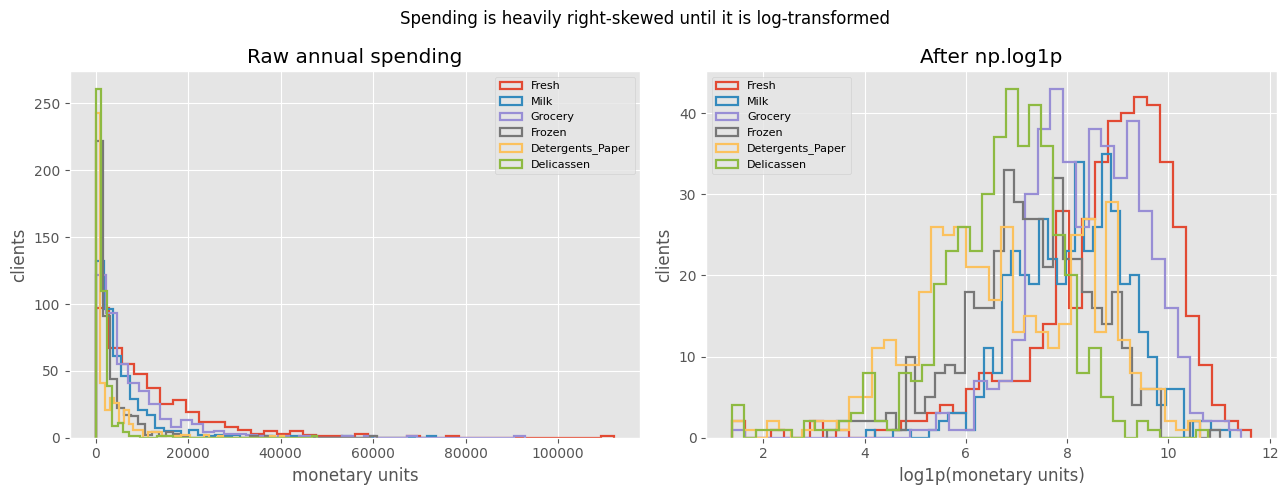

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

for j, name in enumerate(spend_cols):
    ax[0].hist(X_raw[:, j], bins=40, histtype='step', lw=1.6, label=name)
    ax[1].hist(X_log[:, j], bins=40, histtype='step', lw=1.6, label=name)

ax[0].set_title('Raw annual spending')
ax[0].set_xlabel('monetary units')
ax[0].set_ylabel('clients')
ax[0].legend(fontsize=8)

ax[1].set_title('After np.log1p')
ax[1].set_xlabel('log1p(monetary units)')
ax[1].set_ylabel('clients')
ax[1].legend(fontsize=8)

fig.suptitle('Spending is heavily right-skewed until it is log-transformed')
plt.tight_layout()
plt.show()

## The distance matrix

DBSCAN only ever asks one question of the data: which points lie within $\epsilon$ of point $i$.
`pairwise_distances` answers it for every pair at once using
$\lVert a-b \rVert^2 = \lVert a \rVert^2 + \lVert b \rVert^2 - 2\,a \cdot b$, which turns the whole
thing into one matrix product. `np.maximum(d2, 0)` clips the small negative values floating-point
cancellation leaves on the diagonal before the square root.

The result is 440 x 440, about 1.5 MB, and takes a few milliseconds. At this size an $O(n^2)$
matrix is simply the cheapest thing to do: it is computed once and every neighbourhood query
afterwards is a row lookup.

At $n = 10^6$ this is impossible - the matrix alone would be 8 terabytes. Real implementations
never form it. They put the points in a spatial index (a k-d tree, a ball tree, or a uniform grid
of cells of side $\epsilon$) and answer each neighbourhood query in roughly $O(\log n)$, giving
$O(n \log n)$ overall and $O(n)$ memory. The clustering logic below is unchanged by that; only the
`neighbours` lookup would be replaced. Note that k-d trees degrade towards linear scan as
dimensionality rises, which is one reason DBSCAN is normally used in low dimensions.

In [5]:
def pairwise_distances(a):
    sq = np.sum(a ** 2, axis=1)
    d2 = sq[:, None] + sq[None, :] - 2.0 * (a @ a.T)
    np.maximum(d2, 0, out=d2)
    return np.sqrt(d2)


D = pairwise_distances(X)

print('distance matrix:', D.shape, '->', D.nbytes / 1e6, 'MB')
print('smallest non-zero distance: %.6f' % D[D > 0].min())
print('largest distance:           %.6f' % D.max())
print('median distance:            %.6f' % np.median(D[np.triu_indices(len(D), 1)]))

distance matrix: (440, 440) -> 1.5488 MB
smallest non-zero distance: 0.000000
largest distance:           11.798209
median distance:            2.977937


## Choosing eps with the k-distance plot

$\texttt{minPts}$ is set first, because it is the less sensitive of the two. The usual rule of
thumb is $\texttt{minPts} = 2d$ for $d$ dimensions, which gives 12 here for six spending
categories. Larger values make the density estimate steadier and push more points into noise.

$\epsilon$ then comes from the **k-distance plot**. For every point, take the distance to its
$\texttt{minPts}$-th nearest neighbour, counting itself - that is exactly the radius at which the
point would become core. Sort all 440 of those distances and plot them. Points in dense regions
need only a small radius and sit on the flat left part of the curve; points in sparse regions need
a large one and sit on the steep right tail. The **knee** between the two is the natural threshold:
choose $\epsilon$ there and everything on the flat part becomes core, everything past it becomes
noise.

`knee_index` locates it without eyeballing. It rescales the curve into the unit square, draws the
chord from its first point to its last, and returns the index where the curve falls furthest below
that chord - the point of sharpest turn.

In [6]:
MIN_SAMPLES = 12

# distance to the MIN_SAMPLES-th nearest neighbour, self included
D_sorted = np.sort(D, axis=1)
k_dist = np.sort(D_sorted[:, MIN_SAMPLES - 1])


def knee_index(curve):
    n = len(curve)
    x = np.arange(n, dtype=float) / (n - 1)
    y = (curve - curve.min()) / (curve.max() - curve.min())
    return int(np.argmax(np.abs(y - x)))


knee = knee_index(k_dist)
EPS_KNEE = round(float(k_dist[knee]), 2)

print('min_samples =', MIN_SAMPLES)
print('knee at point %d of %d (%.0f%% of points below it)' % (knee, len(k_dist), 100 * knee / len(k_dist)))
print('k-distance at the knee: %.3f  ->  eps = %.2f' % (k_dist[knee], EPS_KNEE))

min_samples = 12
knee at point 376 of 440 (85% of points below it)
k-distance at the knee: 1.778  ->  eps = 1.78


The cell below plots the sorted k-distances with the knee marked. The dashed line is the $\epsilon$
taken from it. A second, tighter value is also marked; the reason for it comes out of the runs
below.

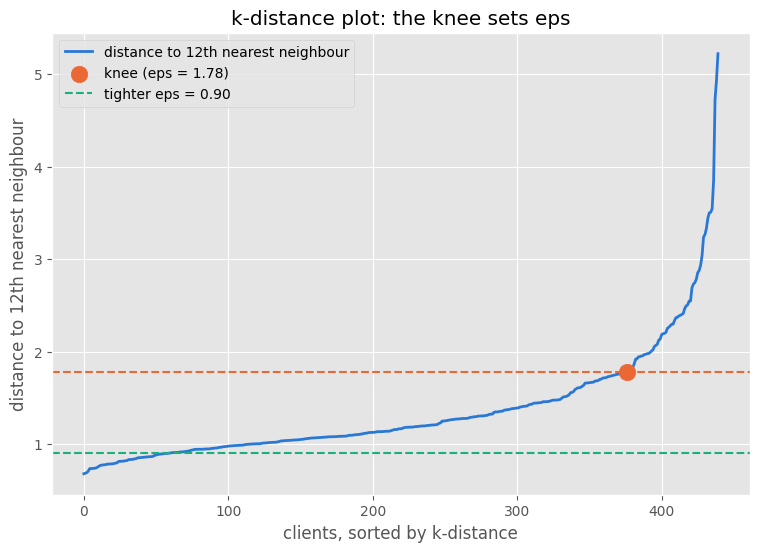

In [7]:
EPS_TIGHT = 0.90

plt.figure(figsize=(9, 6))
plt.plot(np.arange(len(k_dist)), k_dist, color=BLUE, lw=2,
         label='distance to %dth nearest neighbour' % MIN_SAMPLES)
plt.scatter([knee], [k_dist[knee]], color=ORANGE, s=140, zorder=5,
            label='knee (eps = %.2f)' % EPS_KNEE)
plt.axhline(EPS_KNEE, color=ORANGE, ls='--', lw=1.5)
plt.axhline(EPS_TIGHT, color=GREEN, ls='--', lw=1.5,
            label='tighter eps = %.2f' % EPS_TIGHT)

plt.xlabel('clients, sorted by k-distance')
plt.ylabel('distance to %dth nearest neighbour' % MIN_SAMPLES)
plt.title('k-distance plot: the knee sets eps')
plt.legend()
plt.show()

## The DBSCAN class

`fit` runs in two stages.

The first stage builds `neighbours`, a list holding the indices within `eps` of each point, and
marks every point with at least `min_samples` of them as core in `self.core_points`. That single
pass is the whole density model.

The second stage grows the clusters. It walks the points in order; anything that is not core, or
that already carries a label, is skipped. An unlabelled core point starts a new cluster, and its
neighbours go into `queue`. The loop then pops points off `queue`, and each unlabelled one joins
the cluster - this is directly density-reachability being applied. If the point that just joined is
itself core, its own neighbours are appended to `queue`, which is what extends the relation
transitively into density-reachability. The queue is drained in insertion order, so this is a
breadth-first expansion, and it stops exactly when the dense region runs out. Everything absorbed
this way is density-connected through the core points that pulled it in, which is the definition of
a cluster.

A border point is picked up when a core point reaches it, but because it is not core its own
neighbours are never queued, so the cluster does not leak through it. Anything never reached keeps
its initial `-1` and is noise.

`self.labels` holds the cluster number per point with `-1` for noise, `self.core_points` is a
boolean mask, and `self.n_clusters` is the number found. No `k` is passed in anywhere; the count is
whatever the expansion produces.

## How a cluster spreads

The animation below shows the two ideas the class above implements. First the test that sorts
every point into one of three kinds: a circle of radius `eps` is drawn around a point and the
neighbours inside it are counted against

$$\lvert N_\varepsilon(p) \rvert \ge \text{minPts}$$

A point that passes is a **core** point. A point that fails but sits inside some core point's
circle is a **border** point. A point that fails and is in nobody's circle is **noise**.

Then the expansion. Starting from one core point, the cluster claims everything in its circle,
and every newly claimed point that is itself a core point has its own circle claimed in turn. The
cluster therefore creeps along wherever the data stays dense and simply stops when the queue runs
empty - which is why DBSCAN can follow a shape that is not round, and why it never has to be told
how many clusters to find.

Two things about the settings. `minPts = 12` is the value used above. The animation runs in the
two-dimensional projection this notebook already plots rather than in all six dimensions, because
a six-dimensional ball drawn on a plane would contain far more points than it counts - the circle
on screen and the number beside it would disagree. Within that plane the knee rule gives
`eps = 0.85`, reproducing the one-cluster result found above, so the animation uses the tighter
`eps = 0.55` for the same reason this notebook uses `EPS_TIGHT` later: a single cluster shows
nothing growing. That setting finds 2 clusters and refuses 62 clients.

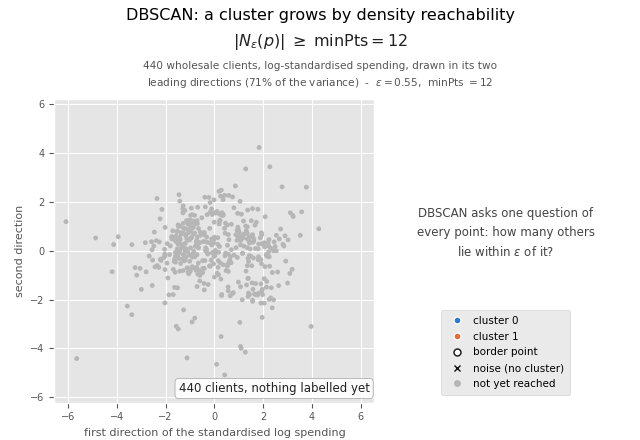

In [ ]:
from IPython.display import Image
Image(filename='../animations/gifs/dbscan_reachability.gif')

In [8]:
class DBSCAN:
    def __init__(self, eps=0.5, min_samples=5):
        self.eps = eps
        self.min_samples = min_samples

    def fit(self, data):
        n = len(data)
        d = pairwise_distances(data)

        # eps-neighbourhood of every point, self included
        neighbours = [np.flatnonzero(d[i] <= self.eps) for i in range(n)]
        counts = np.array([len(v) for v in neighbours])
        self.core_points = counts >= self.min_samples

        labels = np.full(n, -1)
        cluster_id = 0

        for i in range(n):
            # only an unclaimed core point can seed a cluster
            if not self.core_points[i] or labels[i] != -1:
                continue

            labels[i] = cluster_id
            queue = list(neighbours[i])
            head = 0

            # breadth-first expansion over everything density-reachable
            while head < len(queue):
                j = queue[head]
                head += 1
                if labels[j] == -1:
                    labels[j] = cluster_id
                    # only core points extend the chain further
                    if self.core_points[j]:
                        queue.extend(neighbours[j])

            cluster_id += 1

        self.labels = labels
        self.n_clusters = cluster_id
        self.border_points = (labels >= 0) & ~self.core_points
        self.noise_points = labels == -1
        return self

## Running it at the knee

The cell below fits with the $\epsilon$ the knee produced and prints the number of clusters, the
split into core, border and noise, and the noise fraction.

In [9]:
db_knee = DBSCAN(eps=EPS_KNEE, min_samples=MIN_SAMPLES).fit(X)

print('eps = %.2f, min_samples = %d' % (EPS_KNEE, MIN_SAMPLES))
print('clusters found:', db_knee.n_clusters)
print('core points:   %3d' % db_knee.core_points.sum())
print('border points: %3d' % db_knee.border_points.sum())
print('noise points:  %3d  (%.1f%%)' % (db_knee.noise_points.sum(), 100 * db_knee.noise_points.mean()))
print()
for c in range(db_knee.n_clusters):
    print('cluster %d: %d clients' % (c, np.sum(db_knee.labels == c)))

eps = 1.78, min_samples = 12
clusters found: 1
core points:   377
border points:  36
noise points:   27  (6.1%)

cluster 0: 413 clients


The answer at the knee is **one cluster and 27 outliers**. That is a real result about this data,
not a failure to converge: after the log transform the 440 clients form a single connected density
region with no gap wide enough to break the chain of $\epsilon$-balls. Horeca and Retail clients
differ in what they buy, but they shade into one another continuously rather than sitting in two
separated blobs, so there is no low-density valley between them for DBSCAN to cut along.

What DBSCAN does contribute at this setting is the 27 clients it refuses to place - the ones whose
twelfth nearest neighbour is further away than any point on the flat part of the k-distance curve.
The cell below describes them. It compares their median spending against the whole file, counts how
many of their six categories fall outside the 5th-95th percentile band, and checks where the
biggest buyer in each category ended up.

In [10]:
noise_rows = db_knee.noise_points

print('%-17s %12s %12s' % ('feature', 'median all', 'median noise'))
for j, name in enumerate(spend_cols):
    print('%-17s %12.0f %12.0f' % (name, np.median(X_raw[:, j]), np.median(X_raw[noise_rows, j])))

lo = np.percentile(X_raw, 5, axis=0)
hi = np.percentile(X_raw, 95, axis=0)
below = (X_raw < lo).sum(axis=1)
above = (X_raw > hi).sum(axis=1)

print()
print('categories outside the 5th-95th percentile band, per client (mean)')
print('  noise clients:      %.2f below, %.2f above' % (below[noise_rows].mean(), above[noise_rows].mean()))
print('  clustered clients:  %.2f below, %.2f above' % (below[~noise_rows].mean(), above[~noise_rows].mean()))

print()
print('largest single purchase per category, and whether that client was called noise:')
for j, name in enumerate(spend_cols):
    top = int(np.argmax(X_raw[:, j]))
    print('  %-17s %7d  ->  %s' % (name, X_raw[top, j], 'noise' if noise_rows[top] else 'in cluster 0'))

feature             median all median noise
Fresh                     8504          964
Milk                      3627         1698
Grocery                   4756         5091
Frozen                    1526          774
Detergents_Paper           816          334
Delicassen                 966          110

categories outside the 5th-95th percentile band, per client (mean)
  noise clients:      1.81 below, 0.63 above
  clustered clients:  0.20 below, 0.28 above

largest single purchase per category, and whether that client was called noise:
  Fresh              112151  ->  noise
  Milk                73498  ->  in cluster 0
  Grocery             92780  ->  in cluster 0
  Frozen              60869  ->  in cluster 0
  Detergents_Paper    40827  ->  in cluster 0
  Delicassen          47943  ->  noise


The noise set is not simply the biggest spenders. Its median is well below the file median in five
of the six categories, and it carries several times as many out-of-band values per client as the
clustered points do, in both directions. What makes a client noise is having a spending pattern
that nothing else resembles, whether that means buying an enormous amount of one thing or almost
nothing at all of most things. Two of the six category record-holders are in it; the other four
extreme buyers still had eleven neighbours close enough to keep them inside the main region.

## How much the answer depends on eps

Everything above hinges on one number. The cell below refits across a range of $\epsilon$ at fixed
`min_samples` and records the cluster count and the noise fraction at each.

In [11]:
eps_grid = np.arange(0.60, 2.21, 0.02)
n_clusters_grid = []
noise_grid = []

for e in eps_grid:
    m = DBSCAN(eps=float(e), min_samples=MIN_SAMPLES).fit(X)
    n_clusters_grid.append(m.n_clusters)
    noise_grid.append(m.noise_points.mean())

n_clusters_grid = np.array(n_clusters_grid)
noise_grid = np.array(noise_grid)

split = eps_grid[n_clusters_grid >= 2]
print('eps values giving 2 or more clusters: %.2f to %.2f' % (split.min(), split.max()))
print('noise fraction over that window: %.2f to %.2f' % (
    noise_grid[n_clusters_grid >= 2].min(), noise_grid[n_clusters_grid >= 2].max()))

eps values giving 2 or more clusters: 0.76 to 0.94
noise fraction over that window: 0.57 to 0.90


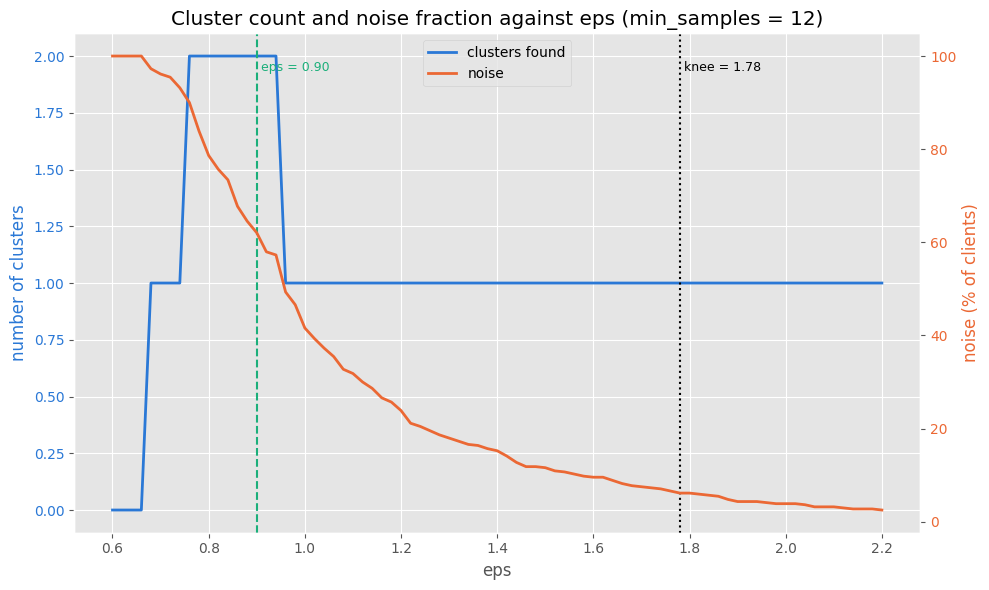

In [12]:
fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.plot(eps_grid, n_clusters_grid, color=BLUE, lw=2, label='clusters found')
ax1.set_xlabel('eps')
ax1.set_ylabel('number of clusters', color=BLUE)
ax1.tick_params(axis='y', labelcolor=BLUE)

ax2 = ax1.twinx()
ax2.plot(eps_grid, 100 * noise_grid, color=ORANGE, lw=2, label='noise')
ax2.set_ylabel('noise (% of clients)', color=ORANGE)
ax2.tick_params(axis='y', labelcolor=ORANGE)
ax2.grid(False)

ax1.axvline(EPS_TIGHT, color=GREEN, ls='--', lw=1.5)
ax1.axvline(EPS_KNEE, color='k', ls=':', lw=1.5)
ax1.text(EPS_TIGHT, ax1.get_ylim()[1] * 0.92, ' eps = %.2f' % EPS_TIGHT, color=GREEN, fontsize=9)
ax1.text(EPS_KNEE, ax1.get_ylim()[1] * 0.92, ' knee = %.2f' % EPS_KNEE, color='k', fontsize=9)

lines = ax1.get_lines()[:1] + ax2.get_lines()[:1]
ax1.legend(lines, [l.get_label() for l in lines], loc='upper center')
ax1.set_title('Cluster count and noise fraction against eps (min_samples = %d)' % MIN_SAMPLES)
plt.tight_layout()
plt.show()

The curve shows the whole behaviour. From $\epsilon \approx 0.96$ upwards there is exactly one
cluster, and raising $\epsilon$ further only shrinks the noise set towards zero. Below
$\epsilon \approx 0.76$ the density requirement is so strict that almost nothing is core and the
noise fraction runs past 90%. Between them is a narrow window, $0.76$ to $0.94$, where the single
region has not yet merged and two dense cores are visible separately - and even at the loosest end
of that window 57% of clients are still noise.

$\epsilon = 0.90$ sits near the top of that window and is used below as a second operating point.
It is not the knee and it is not being presented as a better choice - it is well inside the
territory the k-distance plot marks as too dense. The point of running it is that a one-cluster
result gives nothing to profile or compare, whereas at $0.90$ there is structure to look at,
bought at the cost of a very large noise set.

In [13]:
db = DBSCAN(eps=EPS_TIGHT, min_samples=MIN_SAMPLES).fit(X)

print('eps = %.2f, min_samples = %d' % (EPS_TIGHT, MIN_SAMPLES))
print('clusters found:', db.n_clusters)
print('core points:   %3d' % db.core_points.sum())
print('border points: %3d' % db.border_points.sum())
print('noise points:  %3d  (%.1f%%)' % (db.noise_points.sum(), 100 * db.noise_points.mean()))
print()
for c in range(db.n_clusters):
    print('cluster %d: %d clients' % (c, np.sum(db.labels == c)))
print('%.1f%% of clients were assigned to no cluster at all' % (100 * db.noise_points.mean()))

eps = 0.90, min_samples = 12
clusters found: 2
core points:    60
border points: 107
noise points:  273  (62.0%)

cluster 0: 78 clients
cluster 1: 89 clients
62.0% of clients were assigned to no cluster at all


## Drawing the result

Two views. The first plots two raw spending categories directly, on log axes, since that is what
the clustering ran on: `Detergents_Paper` against `Fresh`, the pair that separates the two client
types most clearly.

The second needs a projection, because the clustering used all six categories. `project_2d`
computes the covariance matrix of `X`, takes its eigenvectors with `np.linalg.eigh`, and keeps the
two with the largest eigenvalues - the two directions along which the standardised log spending
varies most. This is only for drawing; the labels were fixed in six dimensions.

Noise is drawn as grey crosses in both panels so it reads as unassigned rather than as a third
group.

In [14]:
def project_2d(a):
    cov = np.cov(a, rowvar=False)
    vals, vecs = np.linalg.eigh(cov)
    order = np.argsort(vals)[::-1]
    return vecs[:, order[:2]], vals[order] / vals.sum()


axes_2d, var_ratio = project_2d(X)
P = X @ axes_2d
print('variance captured by the two drawn directions: %.1f%%' % (100 * var_ratio[:2].sum()))

variance captured by the two drawn directions: 71.3%


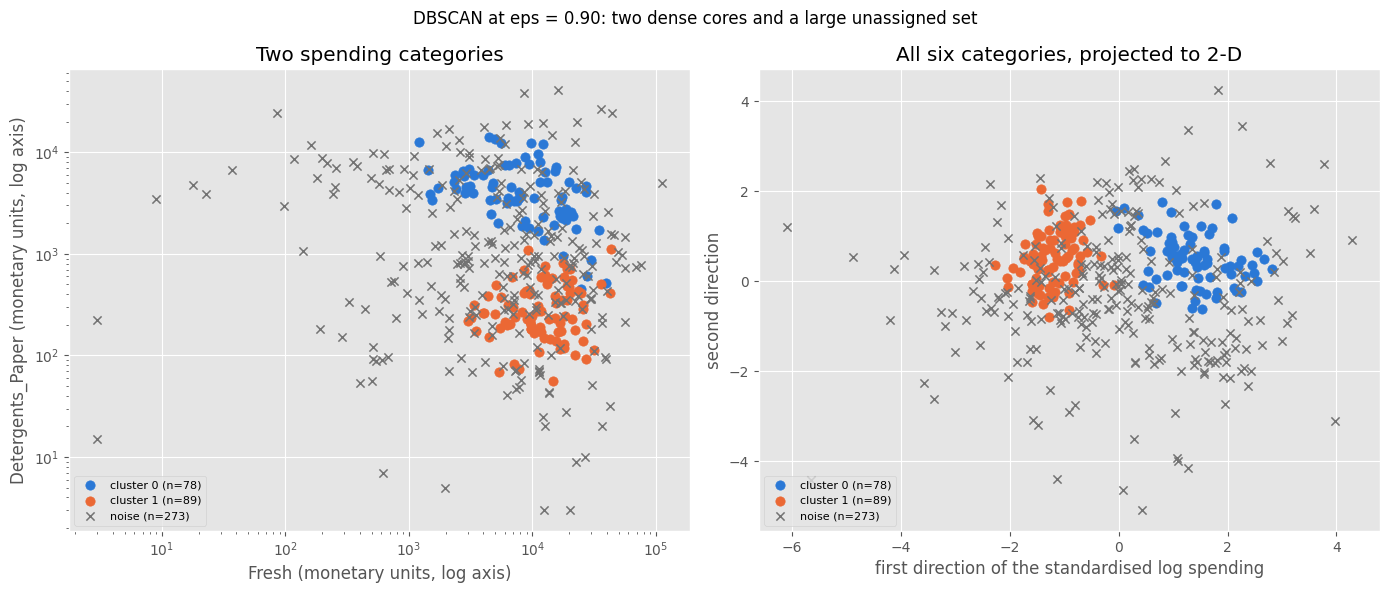

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

fx, fy = spend_cols.index('Fresh'), spend_cols.index('Detergents_Paper')

for c in range(db.n_clusters):
    sel = db.labels == c
    ax[0].scatter(X_raw[sel, fx], X_raw[sel, fy], color=cluster_colors[c], s=45,
                  label='cluster %d (n=%d)' % (c, sel.sum()))
    ax[1].scatter(P[sel, 0], P[sel, 1], color=cluster_colors[c], s=45,
                  label='cluster %d (n=%d)' % (c, sel.sum()))

sel = db.noise_points
ax[0].scatter(X_raw[sel, fx], X_raw[sel, fy], color='0.45', marker='x', s=35, lw=1.1,
              label='noise (n=%d)' % sel.sum())
ax[1].scatter(P[sel, 0], P[sel, 1], color='0.45', marker='x', s=35, lw=1.1,
              label='noise (n=%d)' % sel.sum())

ax[0].set_xscale('log')
ax[0].set_yscale('log')
ax[0].set_xlabel('Fresh (monetary units, log axis)')
ax[0].set_ylabel('Detergents_Paper (monetary units, log axis)')
ax[0].set_title('Two spending categories')
ax[0].legend(fontsize=8, loc='lower left')

ax[1].set_xlabel('first direction of the standardised log spending')
ax[1].set_ylabel('second direction')
ax[1].set_title('All six categories, projected to 2-D')
ax[1].legend(fontsize=8, loc='lower left')

fig.suptitle('DBSCAN at eps = %.2f: two dense cores and a large unassigned set' % EPS_TIGHT)
plt.tight_layout()
plt.show()

## Against k-means

The comparison uses the same input `X` and the same number of clusters DBSCAN found, which is 2.
`kmeans` below is the standard two-step loop: assign every point to its nearest centroid, move
every centroid to the mean of the points that chose it, repeat until nothing moves. Centroids are
seeded from a fixed `RandomState` so the run is reproducible.

The structural difference is in the output, not the objective. `labels_km` contains no `-1` - it
cannot. Every one of the 440 clients gets a centroid, including the extreme spenders, and each of
those outliers pulls its centroid towards itself.

In [16]:
def kmeans(data, k, seed=42, max_iter=300):
    rng = np.random.RandomState(seed)
    centroids = data[rng.choice(len(data), k, replace=False)].copy()

    for _ in range(max_iter):
        d = pairwise_distances(np.vstack([data, centroids]))[:len(data), len(data):]
        labels = np.argmin(d, axis=1)

        moved = centroids.copy()
        for j in range(k):
            if np.any(labels == j):
                moved[j] = data[labels == j].mean(axis=0)

        if np.allclose(moved, centroids):
            break
        centroids = moved

    return labels, centroids


labels_km, centroids_km = kmeans(X, db.n_clusters)

print('k-means with k =', db.n_clusters)
for j in range(db.n_clusters):
    print('  cluster %d: %d clients' % (j, np.sum(labels_km == j)))
print('  unassigned: %d' % np.sum(labels_km < 0))
print()
print('clients DBSCAN called noise: %d' % db.noise_points.sum())
print('  where k-means put them:', np.bincount(labels_km[db.noise_points], minlength=db.n_clusters))

k-means with k = 2
  cluster 0: 188 clients
  cluster 1: 252 clients
  unassigned: 0

clients DBSCAN called noise: 273
  where k-means put them: [114 159]


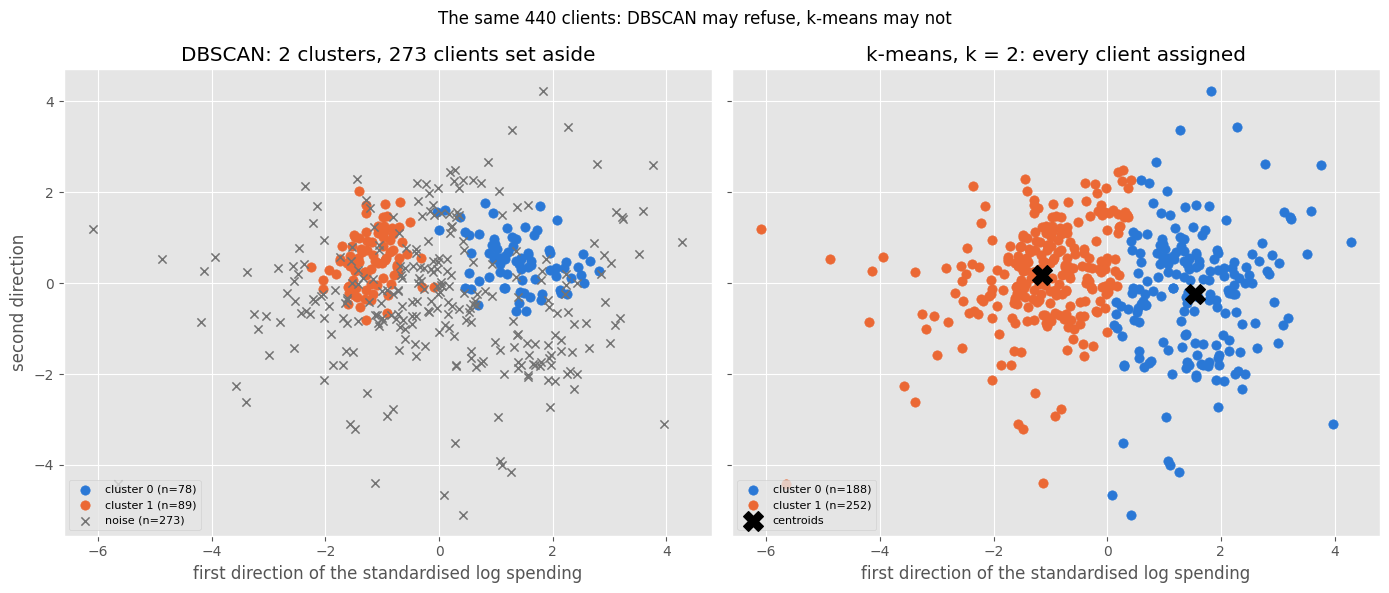

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

for c in range(db.n_clusters):
    sel = db.labels == c
    ax[0].scatter(P[sel, 0], P[sel, 1], color=cluster_colors[c], s=45,
                  label='cluster %d (n=%d)' % (c, sel.sum()))
sel = db.noise_points
ax[0].scatter(P[sel, 0], P[sel, 1], color='0.45', marker='x', s=35, lw=1.1,
              label='noise (n=%d)' % sel.sum())
ax[0].set_title('DBSCAN: %d clusters, %d clients set aside' % (db.n_clusters, sel.sum()))
ax[0].legend(fontsize=8, loc='lower left')

P_cent = centroids_km @ axes_2d
for j in range(db.n_clusters):
    sel = labels_km == j
    ax[1].scatter(P[sel, 0], P[sel, 1], color=cluster_colors[j], s=45,
                  label='cluster %d (n=%d)' % (j, sel.sum()))
ax[1].scatter(P_cent[:, 0], P_cent[:, 1], color='k', marker='X', s=200, lw=1,
              label='centroids')
ax[1].set_title('k-means, k = %d: every client assigned' % db.n_clusters)
ax[1].legend(fontsize=8, loc='lower left')

for a in ax:
    a.set_xlabel('first direction of the standardised log spending')
ax[0].set_ylabel('second direction')

fig.suptitle('The same 440 clients: DBSCAN may refuse, k-means may not')
plt.tight_layout()
plt.show()

The right panel has no grey crosses anywhere. The points scattered around the edges of the cloud
get a colour like everyone else, and both centroids sit where those points helped put them, since
every assigned point enters the mean with equal weight. The left panel keeps them out.

Which is better depends on the question. If the aim is to segment the whole customer base, k-means
answering for all 440 is the useful behaviour and DBSCAN leaving 62% unlabelled is not. If the aim
is to find the clients whose buying pattern is unlike anything else on the books, DBSCAN produces
that list directly and k-means has no way to express it.

## Cluster profiles

The cell below takes the mean raw spending per category within each DBSCAN cluster and within the
noise set, then divides each by the overall median for that category so the six columns are
comparable. A value of 2 means the group spends twice the typical client's amount on that
category. The heatmap makes the two clusters readable as customer types.

In [18]:
groups = [('cluster %d' % c, db.labels == c) for c in range(db.n_clusters)]
groups.append(('noise', db.noise_points))

profile = np.array([X_raw[sel].mean(axis=0) for _, sel in groups])
profile_rel = profile / np.median(X_raw, axis=0)

print('mean annual spending per group (monetary units)')
print('%-12s' % 'group', ''.join('%18s' % c for c in spend_cols))
for i, (name, sel) in enumerate(groups):
    print('%-12s' % name, ''.join('%18.0f' % v for v in profile[i]))

mean annual spending per group (monetary units)
group                     Fresh              Milk           Grocery            Frozen  Detergents_Paper        Delicassen
cluster 0                 11094              8050             11658              1830              4774              2082
cluster 1                 13974              1796              2498              3626               325               971
noise                     11616              6456              8670              3246              3174              1546


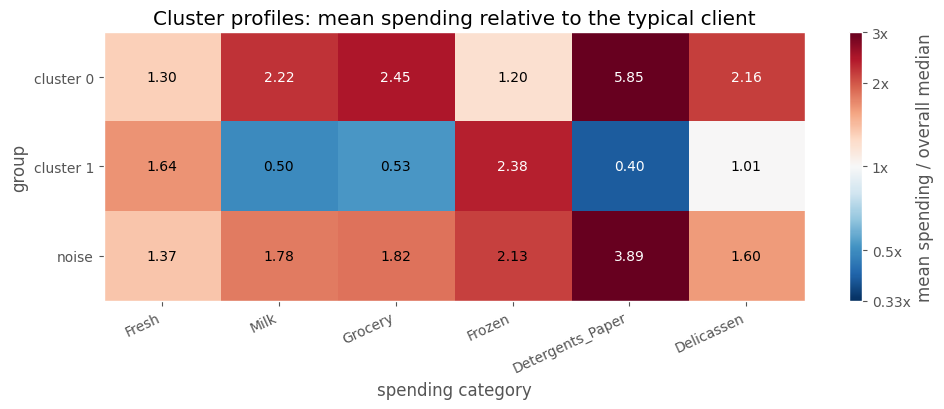

In [19]:
fig, ax = plt.subplots(figsize=(10, 4.2))
ax.grid(False)

# colour on a log2 ratio so under- and over-spending are symmetric about 1
shade = np.log2(profile_rel)
im = ax.imshow(shade, cmap='RdBu_r', vmin=-1.6, vmax=1.6, aspect='auto')

ax.set_xticks(range(len(spend_cols)))
ax.set_xticklabels(spend_cols, rotation=25, ha='right')
ax.set_yticks(range(len(groups)))
ax.set_yticklabels([name for name, _ in groups])

for i in range(profile_rel.shape[0]):
    for j in range(profile_rel.shape[1]):
        ax.text(j, i, '%.2f' % profile_rel[i, j], ha='center', va='center',
                color='w' if abs(shade[i, j]) > 1.1 else 'k', fontsize=10)

cbar = fig.colorbar(im, ax=ax, ticks=[-1.6, -1, 0, 1, 1.6])
cbar.ax.set_yticklabels(['0.33x', '0.5x', '1x', '2x', '3x'])
cbar.set_label('mean spending / overall median')
ax.set_xlabel('spending category')
ax.set_ylabel('group')
ax.set_title('Cluster profiles: mean spending relative to the typical client')
plt.tight_layout()
plt.show()

## Against the held-back Channel label

`Channel` was excluded from everything above. The cell below cross-tabulates it against the DBSCAN
labels, counting noise as its own row, and does the same for k-means so the two can be read
together. `best_match_rate` reads off the majority `Channel` in each cluster and reports what
fraction of the assigned clients that accounts for - for DBSCAN it is computed over assigned
clients only, since the noise set has no cluster to be right or wrong about.

In [20]:
def crosstab(labels, n_clusters, include_noise=True):
    rows = list(range(n_clusters)) + ([-1] if include_noise else [])
    table = np.zeros((len(rows), 2), dtype=int)
    for i, c in enumerate(rows):
        sel = labels == c
        table[i, 0] = np.sum(channel[sel] == 1)
        table[i, 1] = np.sum(channel[sel] == 2)
    return table, rows


def best_match_rate(table):
    return table.max(axis=1).sum() / table.sum()


tab_db, rows_db = crosstab(db.labels, db.n_clusters)
tab_km, rows_km = crosstab(labels_km, db.n_clusters, include_noise=False)

print('DBSCAN (eps = %.2f)          Horeca  Retail' % EPS_TIGHT)
for i, c in enumerate(rows_db):
    name = 'noise' if c == -1 else 'cluster %d' % c
    print('  %-24s %6d  %6d' % (name, tab_db[i, 0], tab_db[i, 1]))
print('  majority-Channel rate over assigned clients only: %.3f' % best_match_rate(tab_db[:-1]))
print()
print('k-means (k = %d)              Horeca  Retail' % db.n_clusters)
for i, c in enumerate(rows_km):
    print('  %-24s %6d  %6d' % ('cluster %d' % c, tab_km[i, 0], tab_km[i, 1]))
print('  majority-Channel rate over all 440 clients:       %.3f' % best_match_rate(tab_km))

DBSCAN (eps = 0.90)          Horeca  Retail
  cluster 0                    19      59
  cluster 1                    88       1
  noise                       191      82
  majority-Channel rate over assigned clients only: 0.880

k-means (k = 2)              Horeca  Retail
  cluster 0                    54     134
  cluster 1                   244       8
  majority-Channel rate over all 440 clients:       0.859


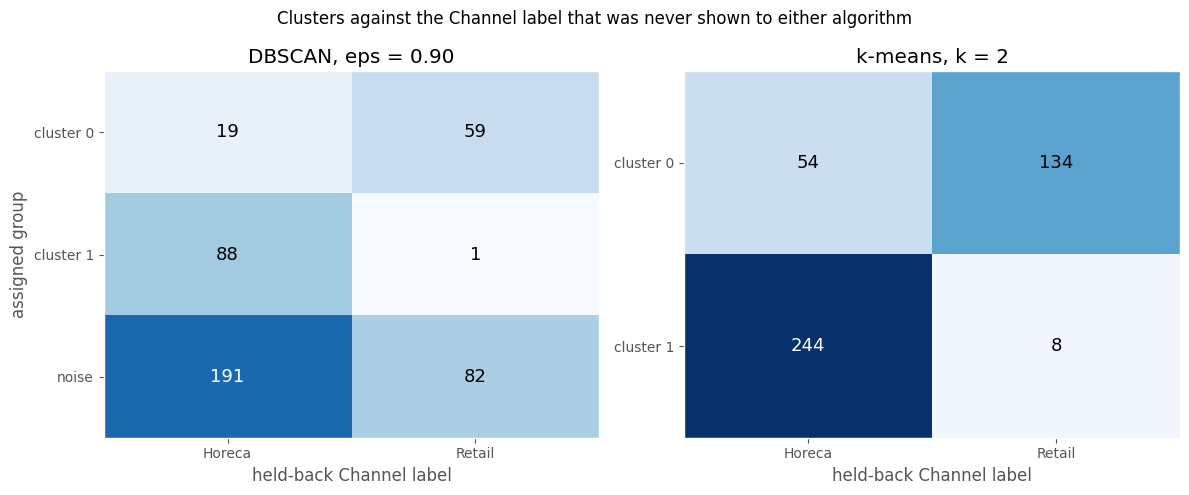

In [21]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

for a in ax:
    a.grid(False)

panels = [
    (ax[0], tab_db, ['cluster %d' % c if c >= 0 else 'noise' for c in rows_db],
     'DBSCAN, eps = %.2f' % EPS_TIGHT),
    (ax[1], tab_km, ['cluster %d' % c for c in rows_km],
     'k-means, k = %d' % db.n_clusters),
]

vmax = max(tab_db.max(), tab_km.max())

for a, table, ylabels, title in panels:
    im = a.imshow(table, cmap='Blues', aspect='auto', vmin=0, vmax=vmax)
    a.set_xticks([0, 1])
    a.set_xticklabels(['Horeca', 'Retail'])
    a.set_yticks(range(len(ylabels)))
    a.set_yticklabels(ylabels)
    for i in range(table.shape[0]):
        for j in range(table.shape[1]):
            a.text(j, i, str(table[i, j]), ha='center', va='center', fontsize=13,
                   color='w' if table[i, j] > vmax * 0.55 else 'k')
    a.set_xlabel('held-back Channel label')
    a.set_title(title)

ax[0].set_ylabel('assigned group')
fig.suptitle('Clusters against the Channel label that was never shown to either algorithm')
plt.tight_layout()
plt.show()

## What the numbers say

Cluster 1 is almost entirely Horeca and cluster 0 is mostly Retail, and the profile heatmap says
why: cluster 1 buys `Fresh` and `Frozen` and very little `Detergents_Paper`, which is a restaurant
or cafe, while cluster 0 buys `Grocery`, `Milk` and `Detergents_Paper` at well above the typical
level, which is a shop. Over the clients DBSCAN was willing to place, the majority `Channel` in
each cluster covers about 88% of them.

That number should not be read as an accuracy score. It is computed over 167 clients, and the other
273 - 62% of the data - were set aside. K-means, working on the same six columns with the same
$k$, reaches a comparable majority rate while assigning all 440. On this dataset, at this
$\epsilon$, DBSCAN identifies the cores of the two channels accurately and then declines to say
anything about the majority of the customer base.

At the $\epsilon$ the k-distance knee actually recommends, DBSCAN's answer was one cluster and 27
outliers. That is the more honest summary of what it found: log-transformed wholesale spending is a
single connected density region with a thin tail, not two separated groups. The Horeca/Retail
distinction is a gradient through that region, and a density-based method has no gap to cut along.

The useful output here is the refusal itself. Neither k-means nor any method that partitions the
whole space can produce a list of clients that belong to no group, and the 27 the knee setting
flags are the ones whose spending mix nothing else in the file resembles. Where DBSCAN earns its
place is data with genuine gaps and genuine outliers - it will find non-convex shapes k-means
cannot, and it will leave the outliers out - and reporting how much of the data it left unlabelled
is part of reporting the result.